In [24]:
# ***********IMPORTING LIBRARIES*********

#File handling and data processing libraries
import os
import glob
import re
#Numerical and data analysis libraries
import numpy as np
import pandas as pd
#Visualization
import matplotlib.pyplot as plt
#Statistical tests
from scipy.stats import f_oneway, ttest_ind, spearmanr

In [25]:
#DEFINE DIRECTORY PATHS

#Paths for raw data, processed data, and outputs
RAW_DIR = "data/raw"
PROCESSED_DIR = "data/processed"
FIGURES_DIR = "outputs/figures"
TABLES_DIR = "outputs/tables"

#Ensuring that required directories exist

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

In [26]:
#LANGUAGE NORMALIZATION FUNCTION

#This function standardizes programming language names and to ensure consistency between Stack Overflow and TIOBE datasets

def normalize_language_name(lang):
    if pd.isna(lang):
        return lang

    lang = str(lang).strip()

    mapping = {
        "Bash/Shell (all shells)": "Bash",
        "Visual Basic (.Net)": "Visual Basic (.Net)",
        "HTML/CSS": "HTML/CSS",
        "Assembly": "Assembly",
        "Cobol": "Cobol",
        "Delphi": "Delphi",
        "Lisp": "Lisp",
        "MATLAB": "MATLAB",
        "Objective-C": "Objective-C",
        "PHP": "PHP",
        "Python": "Python",
        "JavaScript": "JavaScript",
        "TypeScript": "TypeScript",
        "C": "C",
        "C#": "C#",
        "C++": "C++",
        "Java": "Java",
        "Go": "Go",
        "Rust": "Rust",
        "Ruby": "Ruby",
        "Swift": "Swift",
        "Kotlin": "Kotlin",
        "Scala": "Scala",
        "R": "R",
        "Dart": "Dart",
        "Fortran": "Fortran",
        "Lua": "Lua",
        "Ada": "Ada",
        "Julia": "Julia",
        "Perl": "Perl",
        "Prolog": "Prolog",
        "Haskell": "Haskell",
        "SQL": "SQL",
        "Delphi/Object Pascal": "Delphi",
        "Visual Basic": "Visual Basic (.Net)",
        "Assembly language": "Assembly",
        "COBOL": "Cobol",
        "Scractch": "Scratch",
        "Scratch": "Scratch",
    }

    return mapping.get(lang, lang)

In [28]:
#TIOBE DATA PROCESSING ****ENRICHMENT****

#Load all monthly TIOBE files for 2024
tiobe_files = sorted(glob.glob(os.path.join(RAW_DIR, "tiobe_index_*2024.csv")))
tiobe_files

['data/raw/tiobe_index_april2024.csv',
 'data/raw/tiobe_index_august2024.csv',
 'data/raw/tiobe_index_december2024.csv',
 'data/raw/tiobe_index_february2024.csv',
 'data/raw/tiobe_index_january2024.csv',
 'data/raw/tiobe_index_july2024.csv',
 'data/raw/tiobe_index_june2024.csv',
 'data/raw/tiobe_index_march2024.csv',
 'data/raw/tiobe_index_may2024.csv',
 'data/raw/tiobe_index_november2024.csv',
 'data/raw/tiobe_index_october2024.csv',
 'data/raw/tiobe_index_september2024.csv']

In [30]:
#List to store processed monthly datasets

monthly_frames = []

#Loop through each monthly file

for file_path in tiobe_files:
  #Read dataset
    df = pd.read_csv(file_path)

    #Clean column names
    df.columns = [col.strip() for col in df.columns]

    #Identify relevant columns dynamically
    language_col = None
    rating_col = None
    rank_col = None

    for col in df.columns:
        col_lower = col.lower()
        if "programming language" in col_lower:
            language_col = col
        elif "ratings" in col_lower:
            rating_col = col
        elif "rank" in col_lower and "2024" in col_lower:
            rank_col = col


    #Extract only relevant columns
    temp = df[[language_col, rating_col]].copy()
    temp.columns = ["Language", "TIOBE_Rating"]

    #Add rank column if they are available
    if rank_col is not None:
        temp["TIOBE_Rank_2024"] = df[rank_col]
    else:
        temp["TIOBE_Rank_2024"] = pd.NA

     #Clean and normalize language names
    temp["Language"] = temp["Language"].astype(str).str.strip().apply(normalize_language_name)
    #Convert percentage strings to numeric values
    temp["TIOBE_Rating"] = (
        temp["TIOBE_Rating"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
    )

    temp["TIOBE_Rating"] = pd.to_numeric(temp["TIOBE_Rating"], errors="coerce")
    temp["TIOBE_Rank_2024"] = pd.to_numeric(temp["TIOBE_Rank_2024"], errors="coerce")

    #Remove invalid rows
    monthly_frames.append(temp.dropna(subset=["Language", "TIOBE_Rating"]))

In [31]:
#Combine all monthly datasets into one
tiobe_all = pd.concat(monthly_frames, ignore_index=True)

#Compute yearly average popularity scores
tiobe_avg = (
    tiobe_all.groupby("Language", as_index=False)
    .agg(
        Avg_TIOBE_Rating=("TIOBE_Rating", "mean"),
        Avg_TIOBE_Rank=("TIOBE_Rank_2024", "mean"),
    )
    .sort_values("Avg_TIOBE_Rating", ascending=False)
    .reset_index(drop=True)
)

#Round values for readability
tiobe_avg["Avg_TIOBE_Rating"] = tiobe_avg["Avg_TIOBE_Rating"].round(4)
tiobe_avg["Avg_TIOBE_Rank"] = tiobe_avg["Avg_TIOBE_Rank"].round(2)

#Save processed TIOBE DATASET!
tiobe_avg.to_csv(os.path.join(PROCESSED_DIR, "tiobe_2024_avg.csv"), index=False)
tiobe_avg.head(15)

,Language,Avg_TIOBE_Rating,Avg_TIOBE_Rank
0,Python,17.9842,NaN
1,C++,10.3917,NaN
2,C,9.7525,NaN
3,Java,9.0633,NaN
4,C#,6.4000,NaN
5,JavaScript,3.5017,NaN
6,Go,1.9300,NaN
7,Visual Basic (.Net),1.9275,NaN
8,SQL,1.8133,NaN
9,Fortran,1.5942,NaN


In [37]:
#LOAD AND CLEAN STACK OVERFLOW DATA

survey = pd.read_csv(os.path.join(RAW_DIR, "survey_results_public.csv"))
survey.shape

(65437, 114)

In [36]:
df = survey.copy()

#Keep only employed developers
df = df[df["Employment"].fillna("").str.contains("Employed", na=False)]

#Clean salary column
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")
df = df.dropna(subset=["ConvertedCompYearly"])
df = df[df["ConvertedCompYearly"] > 0]

#Remove extreme outliers
lower = df["ConvertedCompYearly"].quantile(0.01)
upper = df["ConvertedCompYearly"].quantile(0.99)
df = df[(df["ConvertedCompYearly"] >= lower) & (df["ConvertedCompYearly"] <= upper)]

#Clean experience column
df["YearsCodePro"] = df["YearsCodePro"].replace({
    "Less than 1 year": 0.5,
    "More than 50 years": 50,
})
df["YearsCodePro"] = pd.to_numeric(df["YearsCodePro"], errors="coerce")
df = df.dropna(subset=["YearsCodePro"])

#Remove missing values in key columns
df = df.dropna(subset=["EdLevel", "RemoteWork", "LanguageHaveWorkedWith"])

#Log transformation for salary
df["LogSalary"] = np.log(df["ConvertedCompYearly"])
df.shape

(21025, 115)

In [18]:
df[["ConvertedCompYearly", "LogSalary", "YearsCodePro"]].describe()

,ConvertedCompYearly,LogSalary,YearsCodePro
count,19456.000000,19456.000000,19456.000000
mean,78396.874332,10.842508,9.877416
std,61607.550002,1.146239,8.281334
min,261.000000,5.564520,0.500000
25%,34370.000000,10.444939,4.000000
50%,65000.000000,11.082143,7.000000
75%,107406.000000,11.584371,14.000000
max,382164.000000,12.853605,50.000000


In [34]:
#LANGUAGE-LEVEL DATASET CREATION

#Split multiple languages into separate rows
lang_df = df.copy()
lang_df["Language"] = lang_df["LanguageHaveWorkedWith"].str.split(";")
lang_df = lang_df.explode("Language")

#Clean language names
lang_df["Language"] = lang_df["Language"].astype(str).str.strip()
lang_df["Language"] = lang_df["Language"].apply(normalize_language_name)

#Remove invalid entries
lang_df = lang_df.dropna(subset=["Language"])
lang_df = lang_df[lang_df["Language"] != ""]

#Merge with TIOBE data (enrichment step)
lang_df = lang_df.merge(tiobe_avg, on="Language", how="left")
lang_df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,LogSalary,Language,Avg_TIOBE_Rating,Avg_TIOBE_Rank
0,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,50.0,90.0,Too long,Easy,7322.0,10.0,8.898639,Assembly,NaN,NaN
1,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,50.0,90.0,Too long,Easy,7322.0,10.0,8.898639,Bash,NaN,NaN
2,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,50.0,90.0,Too long,Easy,7322.0,10.0,8.898639,C,9.7525,NaN
3,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,50.0,90.0,Too long,Easy,7322.0,10.0,8.898639,C++,10.3917,NaN
4,73,I am a developer by profession,18-24 years old,"Employed, full-time;Student, full-time;Indepen...","Hybrid (some remote, some in-person)",Apples,Hobby;School or academic work;Professional dev...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,50.0,90.0,Too long,Easy,7322.0,10.0,8.898639,HTML/CSS,NaN,NaN


In [38]:
#LANGUAGE-LEVEL SUMMARY STATISTICS

#Group data by programming language to compute summary statistics
#This allows us to analyze salary patterns at the language level
language_summary = (
    lang_df.groupby("Language")
    .agg(
        count=("ConvertedCompYearly", "count"),        #Number of developers using each language
        median_salary=("ConvertedCompYearly", "median"),      #Median salary (more robust to outliers)
        mean_salary=("ConvertedCompYearly", "mean"),        #Mean salary (sensitive to extreme values)
        avg_tiobe_rating=("Avg_TIOBE_Rating", "mean"),      #Average TIOBE popularity score (enrichment variable)
    )
    .sort_values("count", ascending=False) #Sort languages by number of observations (most common first)
)
language_summary.head(20) #Display top 20 most common programming languages

,count,median_salary,mean_salary,avg_tiobe_rating
Language,,,,
JavaScript,13216,63694.0,75775.419492,3.5017
SQL,11571,64691.0,77889.344136,1.8133
HTML/CSS,10881,61770.0,73618.144564,NaN
Python,10373,67666.0,81249.883351,17.9842
TypeScript,8979,65799.0,79122.214501,NaN
Bash,7764,75184.0,89073.071226,NaN
Java,6062,60441.0,74434.642857,9.0633
C#,6002,65514.0,76516.863046,6.4000
C++,3953,63694.0,77670.464457,10.3917


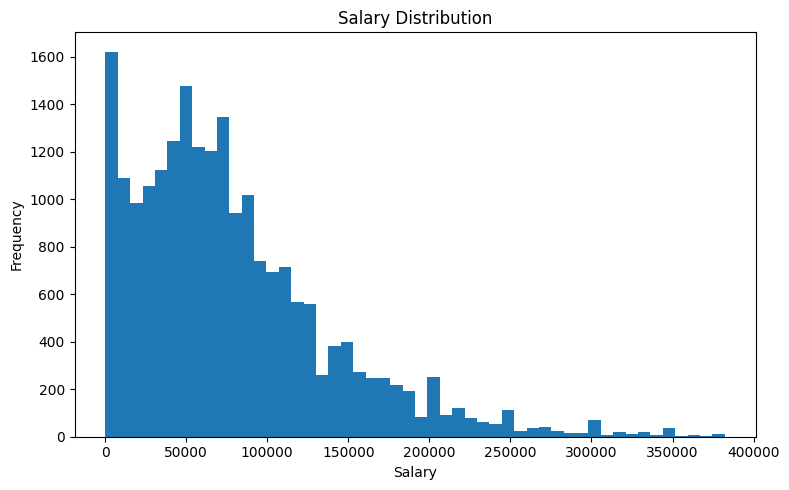

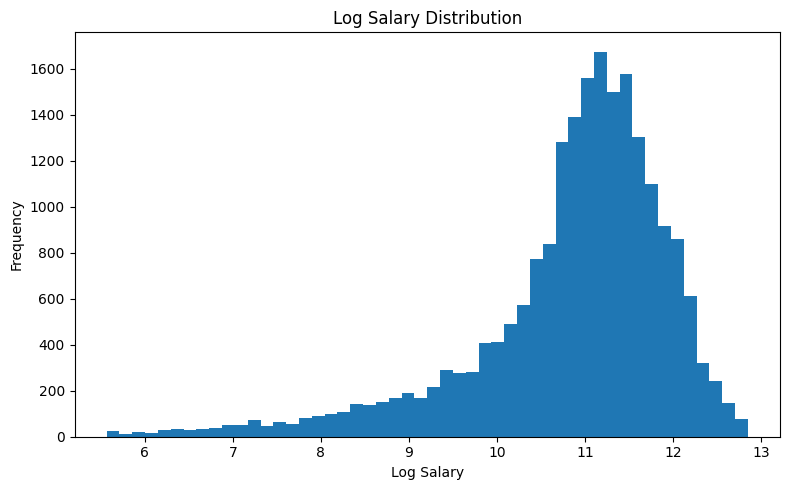

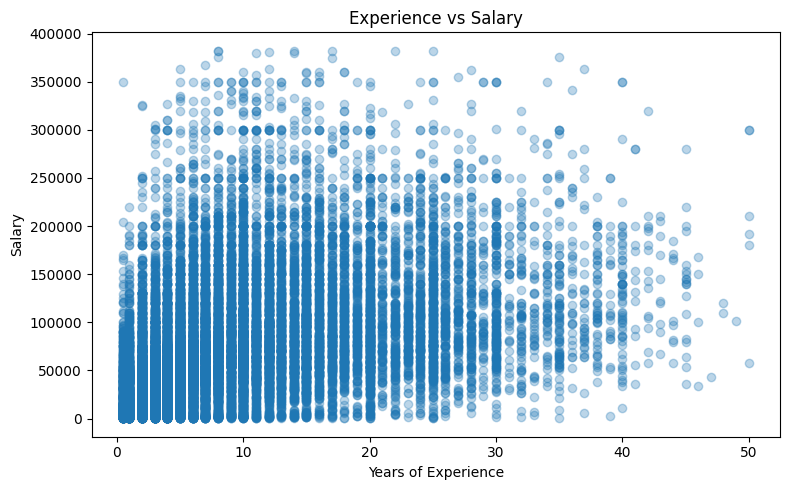

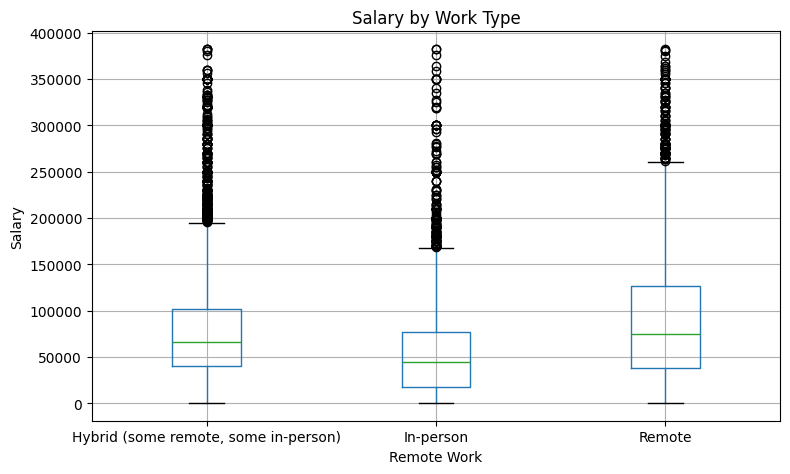

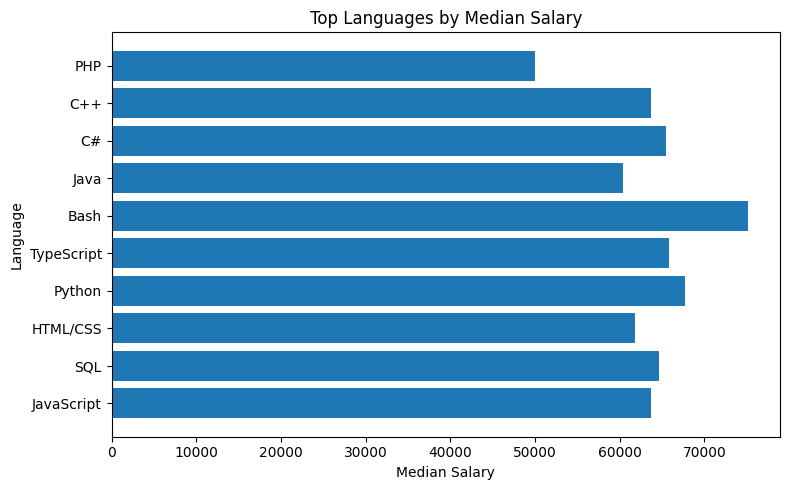

In [44]:
#EXPLORATORY DATA ANALYSIS (EDA)

# --- Salary Distribution ---
plt.figure(figsize=(8, 5))
plt.hist(df["ConvertedCompYearly"], bins=50)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "salary_distribution.png"))
plt.show()
plt.close()

# --- Log Salary Distribution ---
plt.figure(figsize=(8, 5))
plt.hist(df["LogSalary"], bins=50)
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "log_salary_distribution.png"))
plt.show()
plt.close()

# --- Experience vs Salary ---
plt.figure(figsize=(8, 5))
plt.scatter(df["YearsCodePro"], df["ConvertedCompYearly"], alpha=0.3)
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "experience_vs_salary.png"))
plt.show()
plt.close()

# --- Salary by Work Type ---
ax = df.boxplot(column="ConvertedCompYearly", by="RemoteWork", figsize=(8, 5))
plt.title("Salary by Work Type")
plt.suptitle("")
plt.xlabel("Remote Work")
plt.ylabel("Salary")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "salary_by_remote.png"))
plt.show()
plt.close()

# --- Top Languages by Median Salary ---
top_langs = language_summary.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_langs.index, top_langs["median_salary"])
plt.title("Top Languages by Median Salary")
plt.xlabel("Median Salary")
plt.ylabel("Language")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "top_languages_salary.png"))
plt.show()
plt.close()

In [39]:
#HYPOTHESIS TESTING

#****** ANOVA *****: Salary differences across languages
language_counts = lang_df["Language"].value_counts()
eligible_languages = language_counts[language_counts >= 100].index.tolist()

anova_groups = []
used_languages = []

for lang in eligible_languages:
    group = lang_df.loc[lang_df["Language"] == lang, "LogSalary"].dropna()
    if len(group) >= 30:
        anova_groups.append(group)
        used_languages.append(lang)

if len(anova_groups) >= 2:
    f_stat, p_val = f_oneway(*anova_groups)
    print("ANOVA result")
    print("F-statistic:", f_stat)
    print("p-value:", p_val)
    print("Languages used:", used_languages[:15])



ANOVA result
F-statistic: 38.13421971230883
p-value: 8.75e-321
Languages used: ['JavaScript', 'SQL', 'HTML/CSS', 'Python', 'TypeScript', 'Bash', 'Java', 'C#', 'C++', 'PHP', 'C', 'PowerShell', 'Go', 'Rust', 'Kotlin']


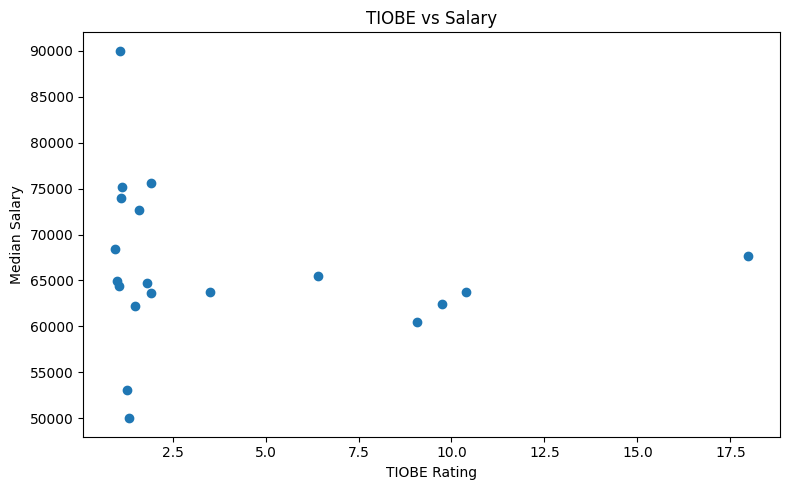

In [46]:
#TIOBE and Salary Graph
plt.figure(figsize=(8, 5))
plt.scatter(corr_df["avg_tiobe"], corr_df["median_salary"])
plt.title("TIOBE vs Salary")
plt.xlabel("TIOBE Rating")
plt.ylabel("Median Salary")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "tiobe_vs_salary.png"))
plt.show()
plt.close()

In [40]:
#Welch t-test: Remote vs In-person
remote_group = df.loc[df["RemoteWork"] == "Remote", "LogSalary"].dropna()
onsite_group = df.loc[df["RemoteWork"] == "In-person", "LogSalary"].dropna()

if len(remote_group) >= 30 and len(onsite_group) >= 30:
    t_stat, p_val = ttest_ind(remote_group, onsite_group, equal_var=False)
    print("Welch t-test result")
    print("t-statistic:", t_stat)
    print("p-value:", p_val)

Welch t-test result
t-statistic: 22.09316251138762
p-value: 1.1624480939433227e-104


In [41]:
#Spearman correlation: Popularity vs Salary
corr_df = (
    lang_df.groupby("Language", as_index=False)
    .agg(
        median_salary=("ConvertedCompYearly", "median"),
        avg_tiobe=("Avg_TIOBE_Rating", "mean"),
        n=("ConvertedCompYearly", "count"),
    )
    .dropna(subset=["avg_tiobe"])
)

corr_df = corr_df[corr_df["n"] >= 30]

if len(corr_df) >= 3:
    rho, p_val = spearmanr(corr_df["avg_tiobe"], corr_df["median_salary"])
    print("Spearman correlation result")
    print("rho:", rho)
    print("p-value:", p_val)

Spearman correlation result
rho: -0.27204917055115696
p-value: 0.2598499882469161
